# 7. Animating the mechanism

Some of what this project does is a **process**, and a process is badly served by a
still picture. A ray sweeping down through the elevation window, a map draining stage by
stage, a score distribution walking under a threshold that never moves — in each case the
intermediate states *are* the argument, and a figure of the end state throws them away.

`tools/make_animations.py` builds eight of these. This notebook builds all eight, says
what each one is for, and shows the frames. It is the only notebook here whose output is
a set of files rather than a set of numbers.

**The filter was strict, and worth stating.** An animation is warranted when the
intermediate states carry the argument — not when the subject happens to be able to
move. Six candidates were rejected on exactly that test: a continuous sweep of the
closing element (`stride_and_closing` already shows the transition, and it is abrupt),
sin α against azimuth (a polar plot does it statically and better), decay probability
against distance and energy (that is a contour plot), the Earth chord against elevation
(one static diagram), Cherenkov footprint growth (a simple monotone relation), and an
array filling a site (decorative). Being able to animate something is not a reason
to.

In [1]:
import os
import sys

# tools/ is a directory of scripts, not an installed package, so it has to be put on the
# path. This is *not* the sys.path-insert that these notebooks otherwise avoid: that one
# pointed at src/ and shadowed an installed oroscope with whatever was in the tree. This
# one reaches a repository tool that is deliberately not shipped.
sys.path.insert(0, os.path.abspath(os.path.join("..", "tools")))
import make_animations as ma

OUT = os.path.abspath(os.path.join("..", "output", "animations"))
print(", ".join(ma.BUILDERS))

the_walk, the_azimuth_fan, the_funnel, stride_and_closing, product_collapse, slope_criterion, tau_in_rock, energy_window


## What is needed to run this

**`ffmpeg`, for the MP4s.** Every cell below writes an MP4 and nothing else; GIFs are a
conversion, covered at the end. Without `ffmpeg` the writes fail and the stills still
appear, which is enough to read the notebook but not enough to have the files.

**A DEM, optionally.** Five of the eight are built from committed code and synthetic
terrain and reproduce on any clone. Three — `the_azimuth_fan`, `product_collapse` and
`slope_criterion` — are about what a criterion does to *real* ground, which synthetic
terrain cannot honestly show, so they read `input/dem/colca.tif` when it is present and
fall back to a synthetic canyon when it is not. Each says on the figure which it used,
so a frame is never ambiguous about what it is a picture of.

Outputs land in `output/animations/`, which is gitignored.

In [2]:
from IPython.display import Image, display


def show_stills(stills, width=760):
    """Stacks a few frames of one animation into one image, small enough to commit.

    A notebook whose outputs live in a repository cannot store a playable video, so what
    it stores is three frames read top to bottom: the beginning, the middle, the end.
    The MP4 written beside it plays.
    """
    import io
    from PIL import Image as PILImage

    frames = [PILImage.open(io.BytesIO(s)).convert("RGB") for s in stills]
    scale = width / max(f.width for f in frames)
    frames = [f.resize((round(f.width * scale), round(f.height * scale)),
                       PILImage.LANCZOS) for f in frames]
    gap = 10
    sheet = PILImage.new("RGB", (width, sum(f.height for f in frames)
                                 + gap * (len(frames) - 1)), "white")
    y = 0
    for f in frames:
        sheet.paste(f, (0, y))
        y += f.height + gap
    buf = io.BytesIO()
    sheet.save(buf, format="JPEG", quality=78, optimize=True)
    display(Image(data=buf.getvalue()))

In [3]:
def build(name, at=(0.0, 0.5, 1.0)):
    """Builds one animation, writes its MP4, and shows stills from the same pass."""
    fig, anim = ma.BUILDERS[name]()
    path, stills = ma.write_mp4_with_stills(name, fig, anim, OUT, at=at)
    print(f"{os.path.relpath(path, '..')}  "
          f"({os.path.getsize(path) / 1024:,.0f} KiB, {anim._save_count} frames)")
    show_stills(stills)

---

## The mechanism, in two halves

Everything downstream — every criterion, every score, every map — rests on one
operation: from a candidate pixel, walk outward along a bearing and find where the ray
first meets terrain. The two animations below are the two axes of that walk.

### `the_walk` — sweeping the elevation

One backward ray sweeping down through the elevation window over a terrain profile. The
first intersection slides along the profile as the angle steepens, and the column depth
behind it accumulates. This is the single hardest thing in the project to convey in
prose, and the reason the elevation binning is nearly free: one pass over the profile
fills every bin at once, because the running maximum of the apparent terrain angle only
ever increases.

Watch the lower panel. Depth is plotted against the **angle being swept**, not against
distance — sharing the x-axis with the profile would make it look like a property of the
terrain, which it is not.

output/animations/the_walk.mp4  (260 KiB, 90 frames)


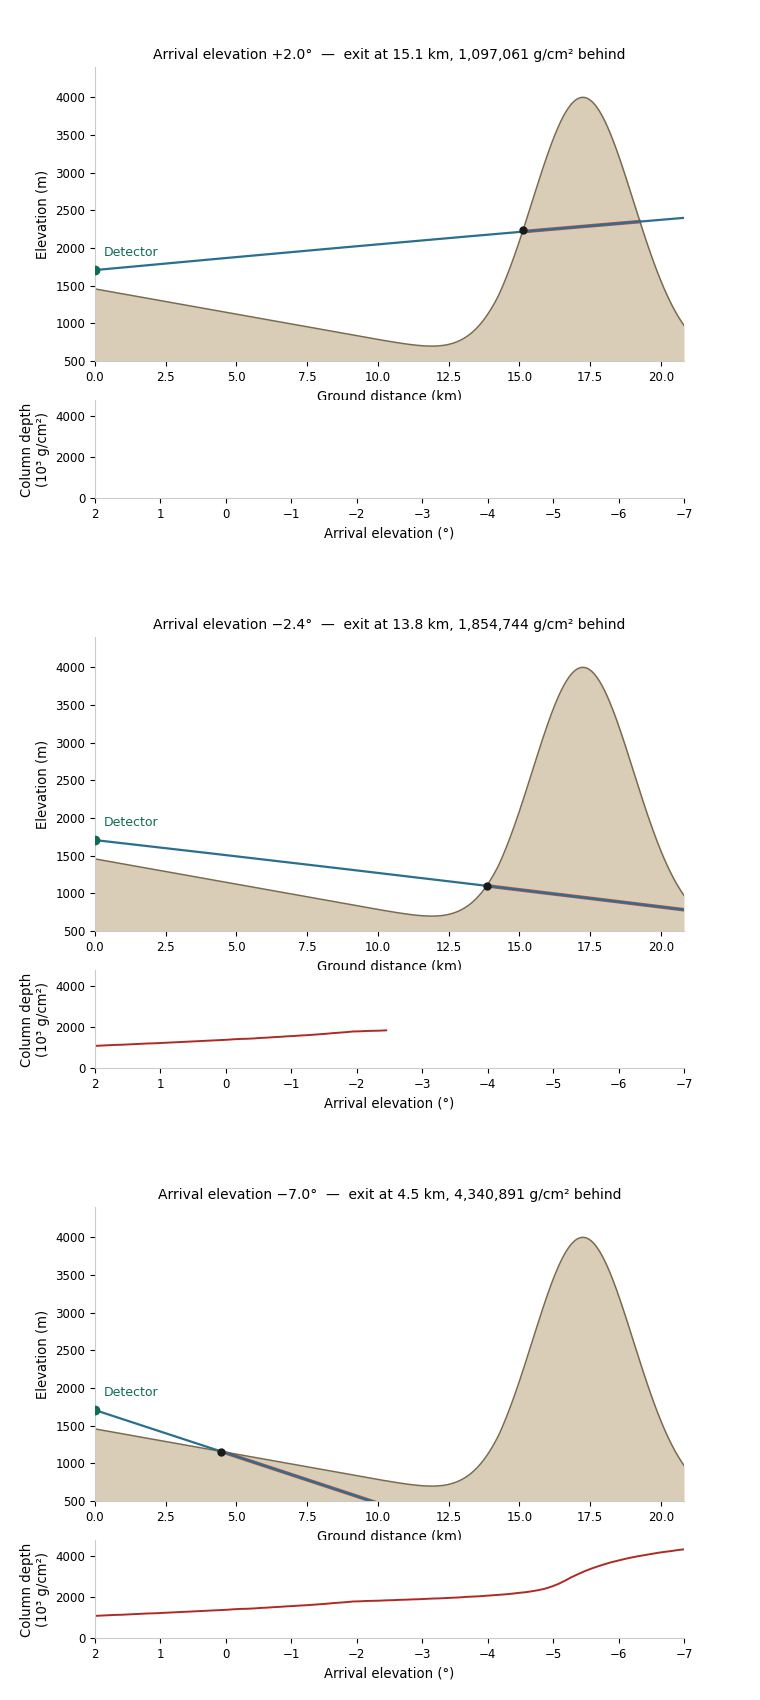

In [4]:
build("the_walk")

### `the_azimuth_fan` — sweeping the bearing

The other half, and the one with no static counterpart. `the_walk` sweeps elevation at a
fixed bearing; this fixes the elevation window and sweeps the bearing through a full
360°, reporting what each one finds.

Three outcomes, and the whole point is that they are not evenly distributed. Bearings
near the candidate's aspect find the far canyon wall at two to three kilometres — inside
the accepted range, steep enough to be a wall. Bearings at right angles find the
candidate's *own* hillside a few hundred metres off, which is rock at the wrong range and
scores nothing. Bearings behind it are blocked at zero. The shaded wedge is the fan the
search actually tests: nine bearings within 60° of aspect, from
`arrival_scan.azimuth_fan(9, 60.0)`.

Acceptance against bearing is a polar quantity, and a polar quantity that changes is
exactly what a still figure renders badly — which is why this one exists and the sin α
version does not.

output/animations/the_azimuth_fan.mp4  (200 KiB, 72 frames)


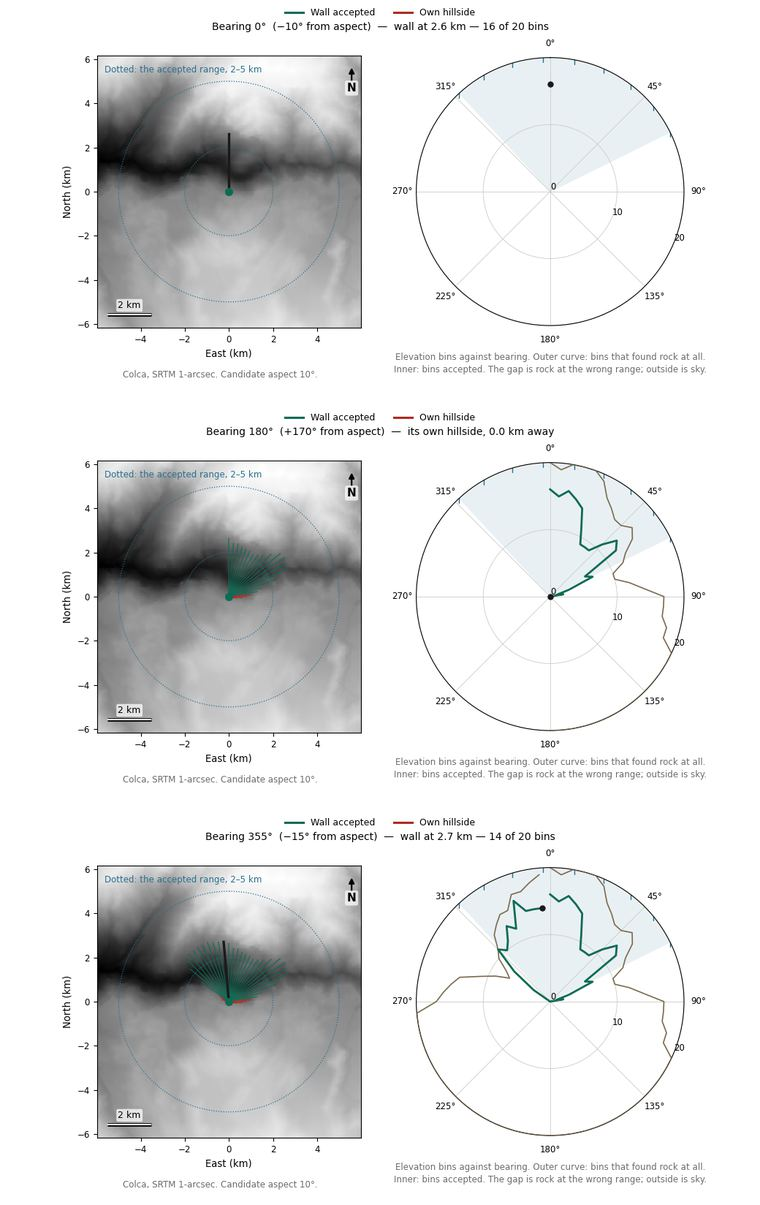

In [5]:
build("the_azimuth_fan")

---

## What the pipeline does to a map

### `the_funnel` — where the candidates went

The funnel table in `--explain` says *how many* candidates each stage removed. It cannot
say **where on the ground** they were. Slope, then stride, then directions accepted, then
gap closing, then pruning — each stage drawn on the map with the surviving count.

The stage that surprises people is closing, which *adds* pixels. It is not a filter; it
is a repair of the holes striding left.

output/animations/the_funnel.mp4  (93 KiB, 48 frames)


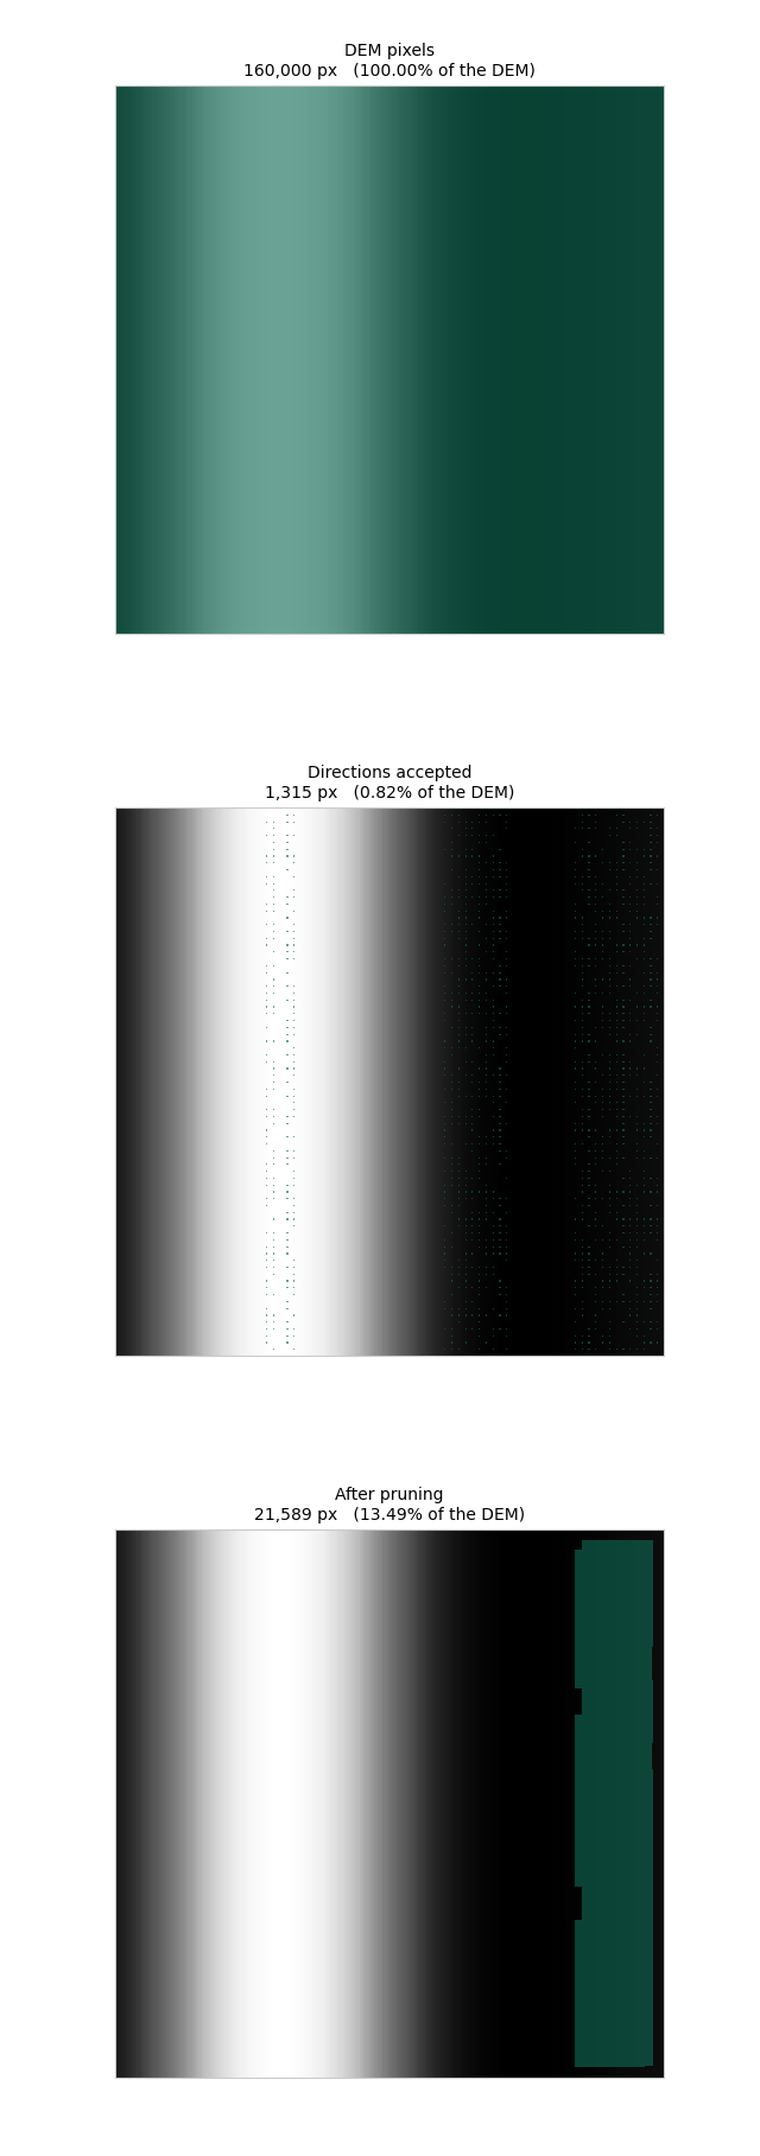

In [6]:
build("the_funnel")

### `stride_and_closing` — why TAMBO's area was low by 4.75×, and is now low by 1.51×

The measurement is in `docs/ROADMAP.md` §6.34 and §6.69; this is what it looks like. A
strided mask closed with an element that bridges the gaps, and the same mask closed with
one that does not.

The transition is **at** the gap and it is abrupt, not gradual: on this mask a 3-pixel
element recovers 0.04× of the accepted set and a 5-pixel one recovers 0.68×, seventeen
times more for two pixels of element. That is the whole story of the spacing change. At
100 m TAMBO's closing element was 3 pixels against a 5-pixel gap, and a real published
area came out **4.75× low** while every intermediate number looked reasonable. At the
published 150 m it is 5 pixels, it lands on the right side of that cliff, and the same
penalty is **1.51×**. Every run now warns (`ss.warn_stride_outruns_closing`).

output/animations/stride_and_closing.mp4  (78 KiB, 70 frames)


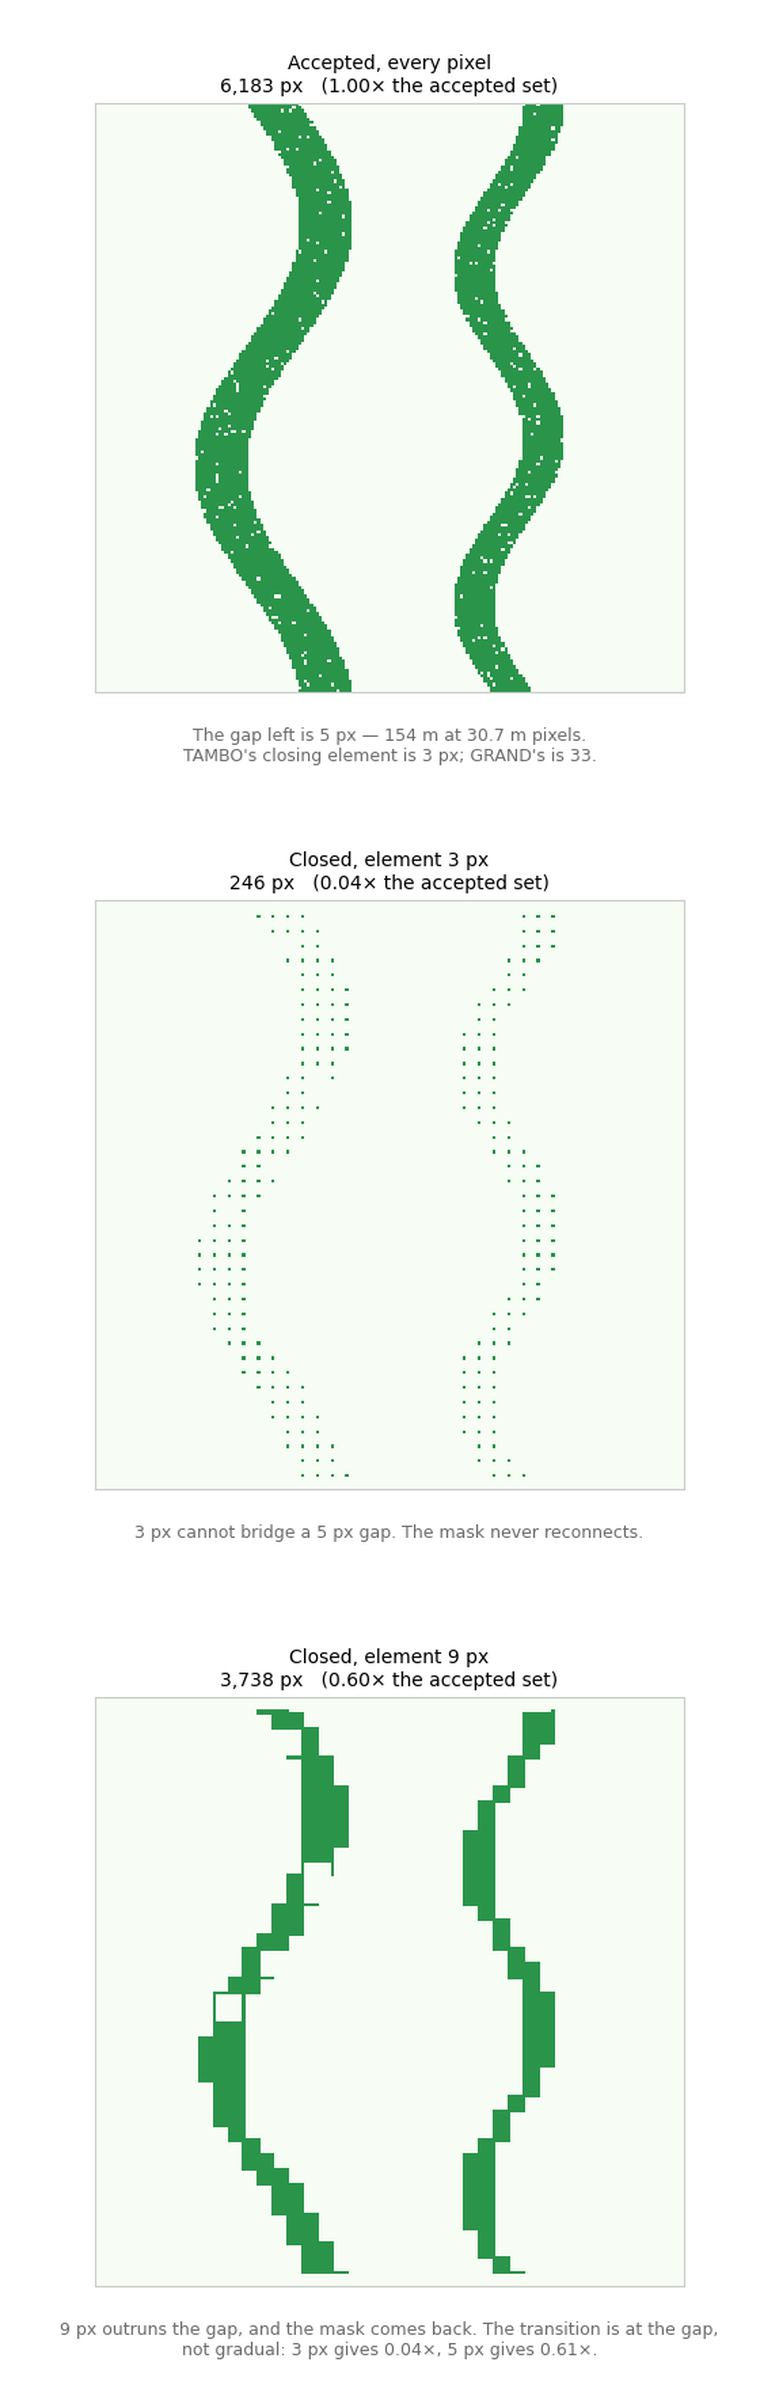

In [7]:
build("stride_and_closing")

### `slope_criterion` — where a criterion bites

The sensitivity sweeps in [notebook 6](06_combining_and_sensitivity.ipynb) say *how
much* a criterion costs. They cannot say *where*. This runs a full arrival scan for each
value of `min_target_slope_deg` and morphs the accepted mask over Colca as the cut climbs
through the wall-slope distribution beside it.

The surroundings go first and the canyon rims hold on longest, which is the criterion
doing exactly what it was written to do — separate a canyon from a hillside.

There is a lesson in the two panels disagreeing. Half the candidates see a mean wall
slope below 29.7°, yet a 30° floor still keeps 87% of them, and the half-way point is not
reached until 50°. **The mask outlives its own median by 20°**, because the criterion is
applied to each *direction* while the histogram is a mean over each candidate's accepted
directions — so a candidate keeps its steepest directions long after its average has
fallen under the cut. Read `target_slope_deg` as a description of a candidate, never as a
prediction of what a cut will do to it.

      0° ->  105,151 candidates


      3° ->  104,570 candidates


      6° ->  104,174 candidates


      9° ->  103,631 candidates


     12° ->  102,897 candidates


...

     60° ->   27,733 candidates


     63° ->   19,997 candidates


     66° ->   12,984 candidates


     69° ->    7,541 candidates


output/animations/slope_criterion.mp4  (866 KiB, 72 frames)


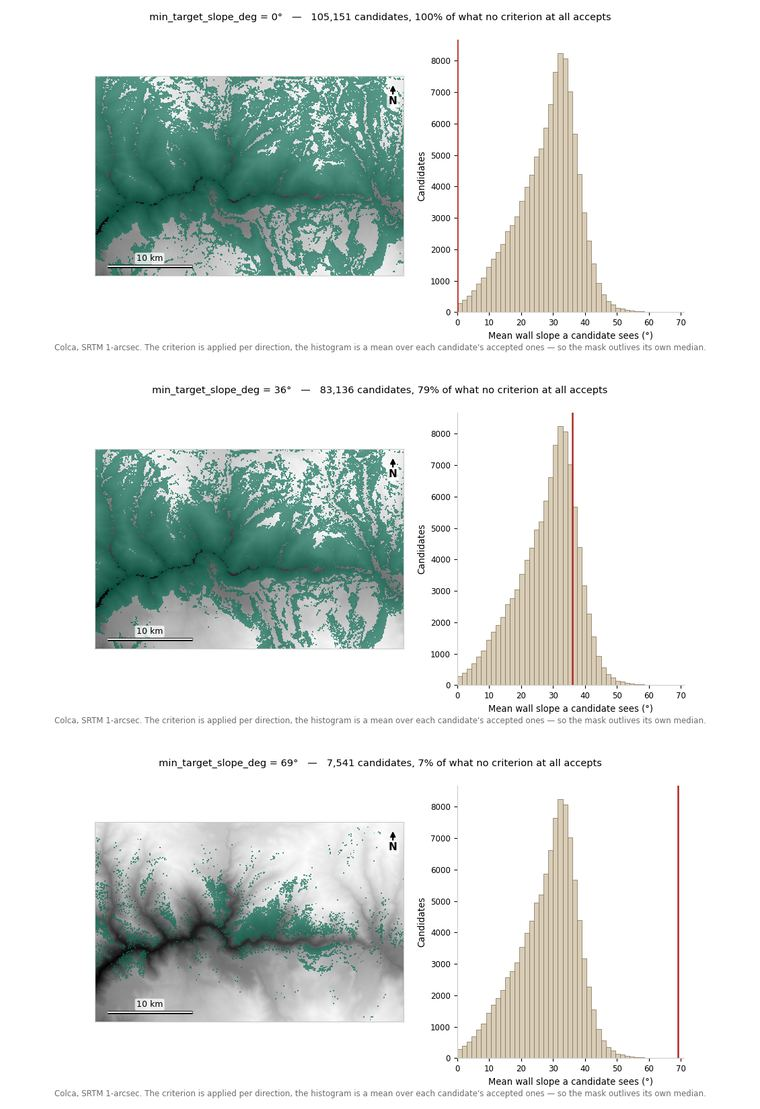

In [8]:
build("slope_criterion")

---

## What the score does

### `product_collapse` — why a threshold on a product is treacherous

`min_score` is the dominant assumption in this project, and the reason a product
threshold is dangerous is **dynamic**: each component multiplied in drags the whole
population toward zero while the cut stays exactly where it was put. Six real components
of a real search, folded in one at a time, against TAMBO's own cut of 0.35. The weight of
the newest component ramps from 0 to 1 — under a product composition weights *are*
exponents, so every intermediate frame is a state `scoring.compose` can genuinely
produce, not a dissolve between two pictures.

Then measurement contradicted the premise, which is the useful part. The collapse is
real — 100% of viable candidates above the cut before any component, 32.2% after six —
but it is **not evenly shared**. `solid_angle` alone takes it from 100% to 35.9%.
`depth` does nothing, because Colca's walls sit inside the default band. And `distance`
does nothing *provably*: the scan already applied the same 2–5 km window as a hard
criterion, so every surviving candidate scores 1 on it by construction. Scoring a
criterion the scan has already enforced is free, but it is also empty.

That sharpens the case against thresholding a product rather than weakening it. The cut
goes from harmless to decisive on the addition of a single term — and which term that is
depends on the terrain, not on the configuration.

output/animations/product_collapse.mp4  (164 KiB, 90 frames)


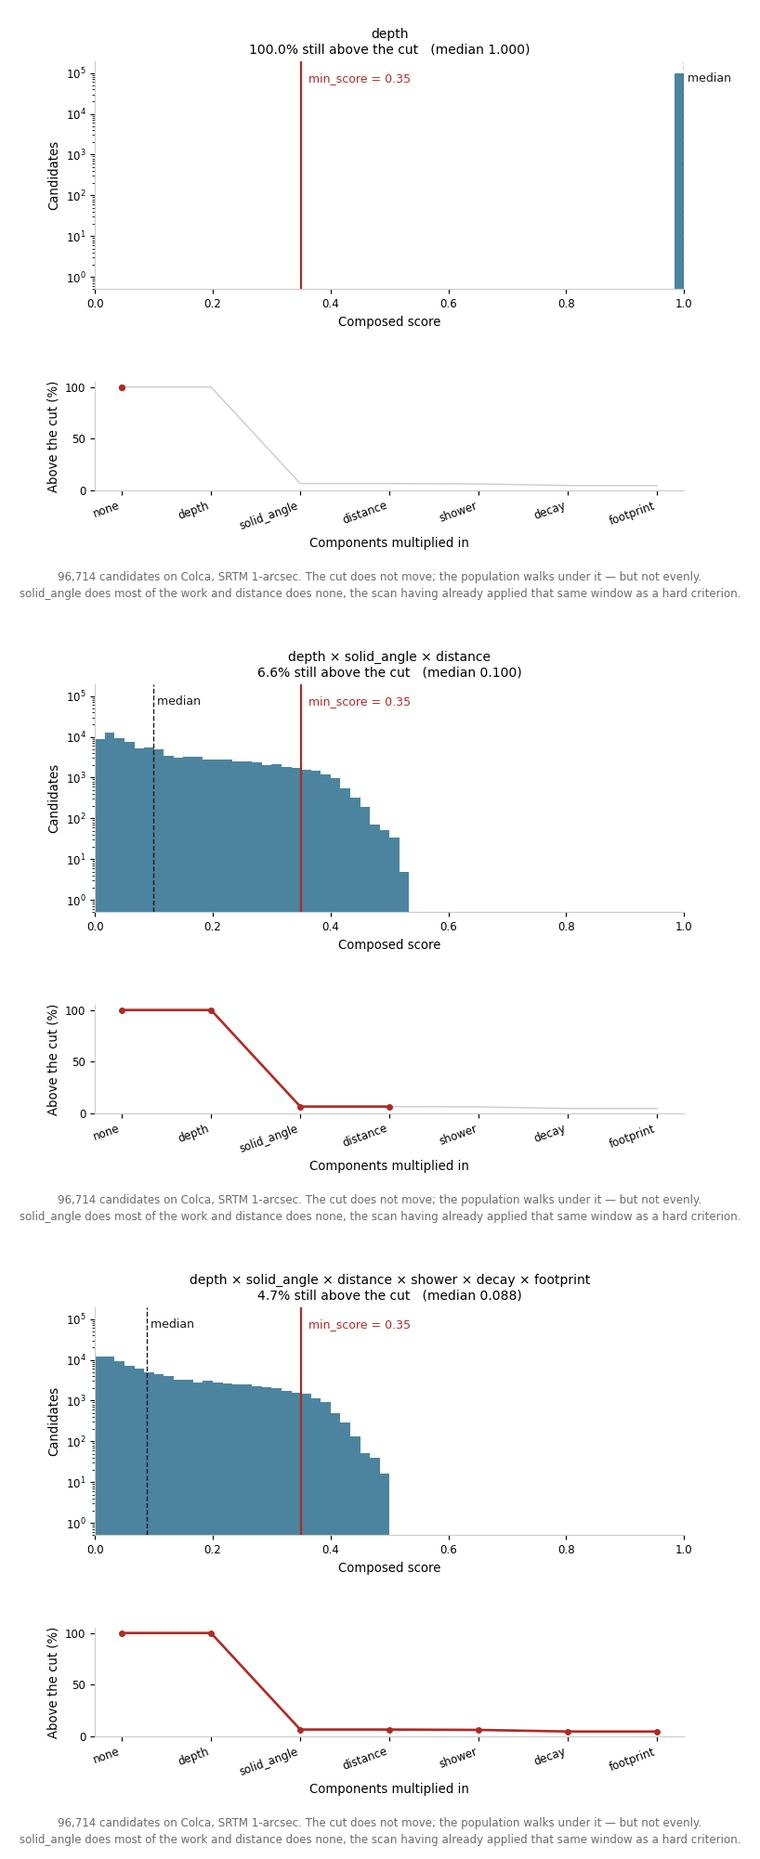

In [9]:
build("product_collapse")

---

## What the physics says

### `tau_in_rock` — more rock is not better

The commonest misconception in this problem, corrected. A tau's energy and its survival
probability both falling as it burrows, against the column depth that maximises
production and escape *together*: `physics.production_escape_optimum_gcm2` gives
5.7×10⁶ g/cm² at 1 EeV, about 22 km of standard rock.

Production grows with the rock available — more target, more neutrino interactions.
Escape collapses once the depth passes the tau's range. Their product therefore has a
maximum, which is why the criterion is a **band** and not a floor. The code has always
had this right; until now it lived only in prose.

output/animations/tau_in_rock.mp4  (139 KiB, 90 frames)


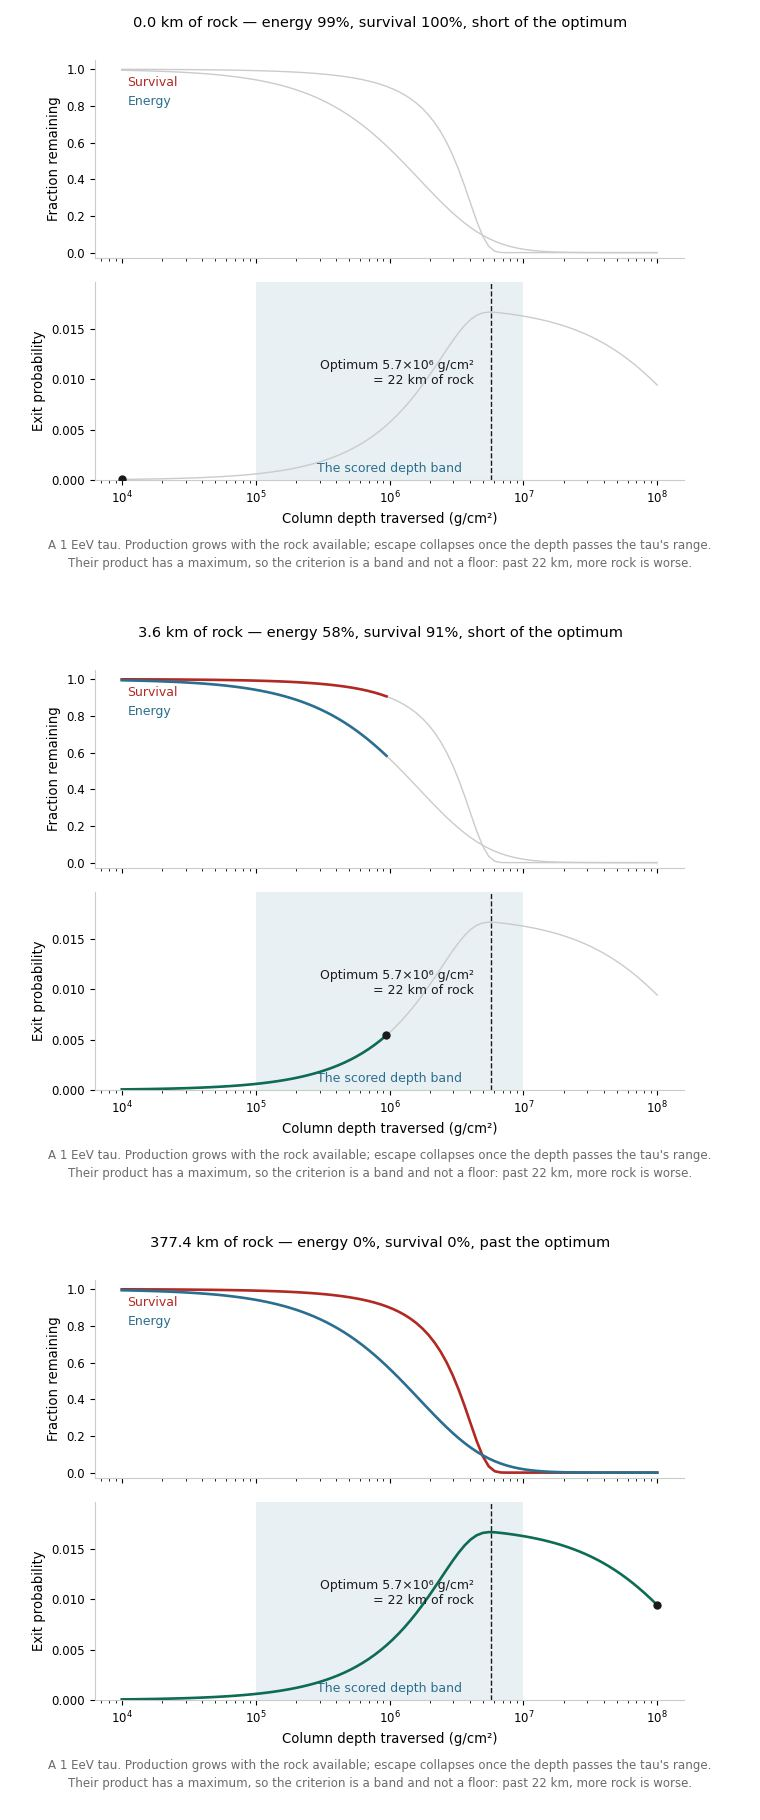

In [10]:
build("tau_in_rock")

### `energy_window` — a prediction, animated over what it predicts

The arrival window narrowing as the energy rises, its lower edge climbing from −4.4° at
100 PeV to −0.9° at 10 EeV as Earth absorption removes the steeply upgoing directions.

This one is here for a different reason from the rest. It is not an explanation of
something the code does; it is a **falsifiable claim about the world** that the code
makes, and nothing in this project has yet been checked against an external simulation.
It is the cheapest such test available and it is ready for someone to run.

output/animations/energy_window.mp4  (104 KiB, 80 frames)


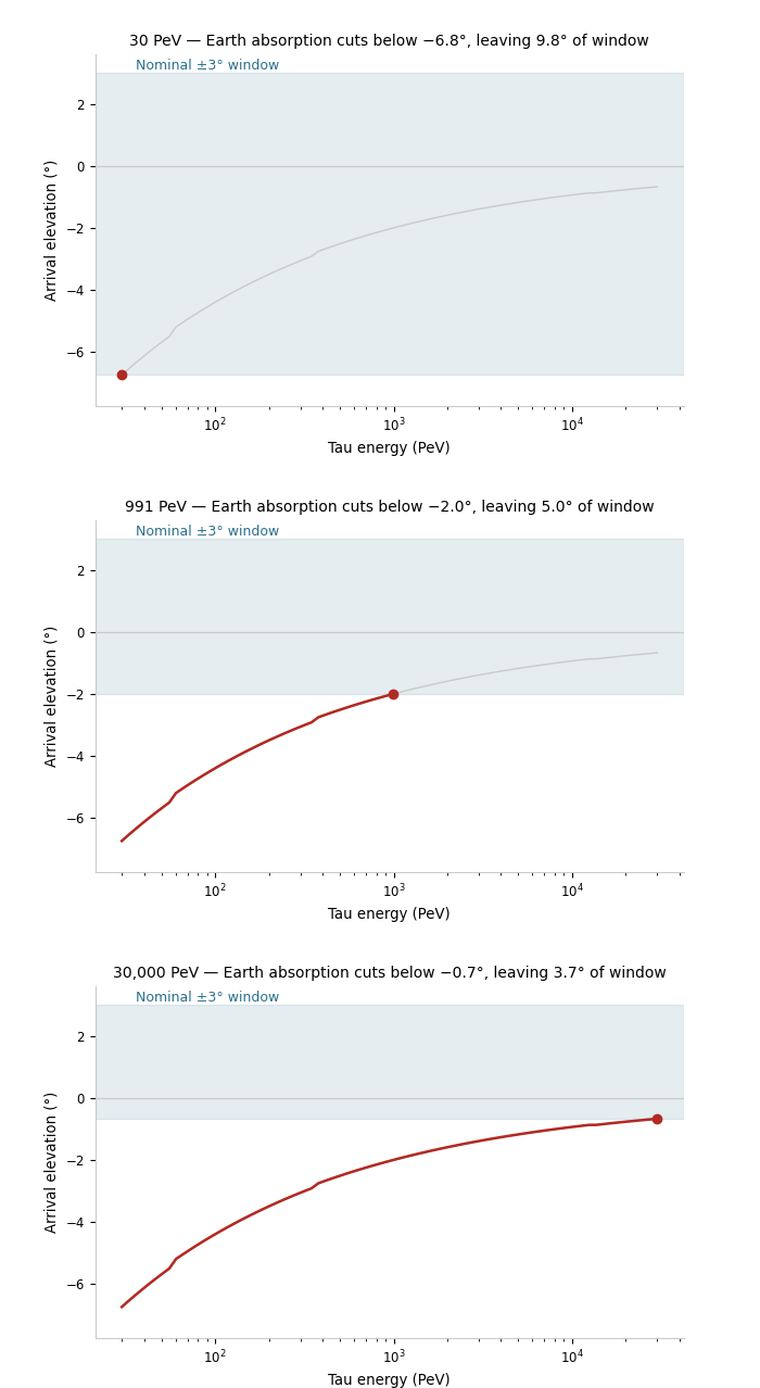

In [11]:
build("energy_window")

---

## Turning an MP4 into an animated GIF

Everything above wrote MP4 only. MP4 is the right format to produce: it is a tenth the
size at the same quality, and it seeks. But a GIF plays inline in places an MP4 does not
— a GitHub README, a wiki, a chat message, a slide that has to survive someone else's
projector — so the conversion is worth having.

**Route one: ask the tool.** `make_animations.py` writes both formats by default and
takes `--format`, so the GIF never needs a conversion step at all:

```bash
python tools/make_animations.py --format gif                 # GIFs only
python tools/make_animations.py --format mp4,gif             # both, the default
python tools/make_animations.py --only the_walk --format gif # one of them
```

This route falls back to pillow when `ffmpeg` is absent, so it always produces
*something*. It is the right choice when the animation is being built now.

**Route two: convert an MP4 you already have.** This is the one to use for a file that
came from somewhere else, or when the MP4 took twenty seconds of terrain scanning to
produce and rebuilding it to change the format would be silly. Plain `ffmpeg`, in one
pass:

```bash
ffmpeg -i the_walk.mp4 \
  -vf "fps=12,scale=900:-1:flags=lanczos,split[s0][s1];[s0]palettegen[p];[s1][p]paletteuse" \
  -y the_walk.gif
```

The `palettegen`/`paletteuse` pair is what makes this worth doing properly. A GIF holds
256 colours; without a palette built from the actual footage, `ffmpeg` falls back to a
fixed web palette and shaded terrain bands horribly. With it, the same animation came out
**342 KiB against pillow's 761 KiB** and looked better.

Three knobs, in the order you will want them:

| | |
|---|---|
| `fps=12` | Match `ma.FPS`. Raising it above what was rendered duplicates frames and inflates the file for nothing. |
| `scale=900:-1` | Width in pixels; `-1` keeps the aspect ratio. This is the strongest size lever by far. |
| `-ss`/`-t` | Trim, if only part of the animation is wanted: `-ss 2 -t 4` takes four seconds from the two-second mark. |

To convert everything in one go:

```bash
cd output/animations
for f in *.mp4; do
  ffmpeg -loglevel error -i "$f" \
    -vf "fps=12,scale=900:-1:flags=lanczos,split[s0][s1];[s0]palettegen[p];[s1][p]paletteuse" \
    -y "${f%.mp4}.gif"
done
```

**If `ffmpeg` is unavailable**, route one still works — pillow is a hard dependency of
matplotlib, so `--format gif` cannot fail for want of an encoder. The files are larger
and the colours are worse, and for a talk that is usually a fine trade.

## Stills, for a paper

`ma.write_mp4_with_stills` returns the frames it grabbed along with the path it wrote, so
a figure for a paper or a slide costs nothing beyond the animation that was being built
anyway. It is one function rather than two for a reason worth knowing if you extend the
tool: **the builders accumulate.** The ray drawn at frame 30 is still on the axes at
frame 60, which is what makes the fan fill in — so the frames can be walked exactly once.
A second pass would start with everything already drawn, and its "first" frame would be a
lie.

In [12]:
fig, anim = ma.BUILDERS["energy_window"]()
path, stills = ma.write_mp4_with_stills("energy_window", fig, anim, OUT,
                                        at=(0.0, 0.35, 0.7, 1.0))
print(f"{len(stills)} stills at the video's own frame size, "
      f"{sum(len(s) for s in stills) / 1024:,.0f} KiB of PNG")

4 stills at the video's own frame size, 97 KiB of PNG


## Where to go next

- **[2. The arrival scan](02_the_arrival_scan.ipynb)** — the walk that `the_walk` and
  `the_azimuth_fan` animate, in code.
- **[4. Criteria and scoring](04_criteria_and_scoring.ipynb)** — the component shapes
  that `product_collapse` multiplies together.
- **[9. Arequipa, the full DEM](09_arequipa_dem.ipynb)** — what the whole machine
  produced when it was finally pointed at everything.
- **[12. Peru, all of it](12_peru_dem.ipynb)** — the same machine pointed at a
  country, and how to read a coarse answer honestly.

---

*Part of the [Oroscope](https://github.com/mbustama/oroscope) tutorials. Previous: [Combining and sensitivity](06_combining_and_sensitivity.ipynb). Next: [Explaining a run](08_explaining_a_run.ipynb). Full API reference: [oroscope docs](https://mbustama.github.io/oroscope/functions.html).*